### Импорт сторонних библиотек

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import sklearn
import catboost
from scipy import stats
import missingno as msno
import numpy as np
from matplotlib.ticker import  FormatStrFormatter
from urllib.parse import urlparse, parse_qs
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error
from sklearn.model_selection import train_test_split 
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
import pickle
import re

### Соединение Датасетов

In [4]:
df_s = pd.read_csv('data/ga_sessions.csv') #импорт ДФ с сессиями
df_s.head()

C:\Users\Toshik\AppData\Local\Temp\ipykernel_24216\3049758019.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_s = pd.read_csv('data/ga_sessions.csv') #импорт ДФ с сессиями


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [5]:
print(df_s.shape)

(1860042, 18)


In [6]:
df_h = pd.read_csv('data/ga_hits.csv')
df_h.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [7]:
print(df_h.shape)

(15726470, 11)


In [8]:
df = pd.merge(df_s, df_h, on='session_id', how='left')
df.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,2021-11-24,3665.0,3.0,event,NaN,podpiska.sberauto.com/,sub_page_view,sub_landing,NaN,NaN
1,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,2021-11-24,46592.0,4.0,event,NaN,podpiska.sberauto.com/,sub_button_click,sub_view_cars_click,vodKSlUobUWTVlgsJqdI,NaN
2,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,...,2021-11-14,921.0,3.0,event,NaN,podpiska.sberauto.com/,sub_page_view,sub_landing,NaN,NaN
3,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,2021-12-28,84155.0,10.0,event,NaN,sberauto.com/cars?utm_source_initial=sbol&utm_...,search_form,search_form_region,KWTCzSIXzoqUWjfUQMgP,NaN
4,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,2021-12-28,102979.0,13.0,event,NaN,sberauto.com/cars?utm_source_initial=sbol&utm_...,search_form,search_form_region,CBqnBQaKoQUyWJhLcxxN,NaN


In [9]:
print(df.shape)

(15812995, 28)


#### Проверка правильного соединения датасетов.

In [11]:
unique_hits_ids = df_h['session_id'].unique()
unique_sessions_ids = df_s['session_id'].unique()
hits_not_in_sessions_df = df_h[~df_h['session_id'].isin(unique_sessions_ids)]
sessions_not_in_hits = set(unique_sessions_ids) - set(unique_hits_ids)
print(f"Количество записей в df_h, session_id которых отсутствуют в df_s: {len(hits_not_in_sessions_df)}")
print(f"Количество session_id, присутствующих в df_sessions, но отсутствующих в df_hits: {len(sessions_not_in_hits)}")

Количество записей в df_h, session_id которых отсутствуют в df_s: 41251
Количество session_id, присутствующих в df_sessions, но отсутствующих в df_hits: 127776


In [12]:
#Если датасеты соеденены правильно то выражение бует равно длинне df
chek_summ=len(df_h)-len(hits_not_in_sessions_df)+len(sessions_not_in_hits)
print(f"Проверочная сумма:{chek_summ}")
print(f"Длинна финального датасета:{len(df)}")

Проверочная сумма:15812995
Длинна финального датасета:15812995


# Data Preparation

## Обработка датасета

### Целевое действие

Опытным путем необходимо оставить как можно больше целевых действий в выборке, поэтому выводим его до всех этапов сокращения датасета. 

In [17]:
df=df.dropna(subset=['event_action'])

In [18]:
target_actions = [ #это мои целевые действия по заданию
    'sub_car_claim_click',
    'sub_car_claim_submit_click',
    'sub_open_dialog_click',
    'sub_custom_question_submit_click',
    'sub_call_number_click',
    'sub_callback_submit_click',
    'sub_submit_success',
    'sub_car_request_submit_click'
]
df['target_action'] = df['event_action'].isin(target_actions)
df.head(5)
counts = df['target_action'].value_counts()

print(counts)

target_action
False    15582377
True       102842
Name: count, dtype: int64


### Анализ типов данных

In [20]:
df.columns # в описании не было колонки 'utm_adcontent'

Index(['session_id', 'client_id', 'visit_date', 'visit_time', 'visit_number',
       'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
       'utm_keyword', 'device_category', 'device_os', 'device_brand',
       'device_model', 'device_screen_resolution', 'device_browser',
       'geo_country', 'geo_city', 'hit_date', 'hit_time', 'hit_number',
       'hit_type', 'hit_referer', 'hit_page_path', 'event_category',
       'event_action', 'event_label', 'event_value', 'target_action'],
      dtype='object')

In [21]:
df.describe(include='all')

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value,target_action
count,15685219,1.568522e+07,15685219,15685219,1.568522e+07,15684519,15685219,13486346,12852801,6480392,...,6.525016e+06,1.568522e+07,15685219,9449721,15685219,15685219,15685219,11957537,0.0,15685219
unique,1732266,1.320702e+06,226,85032,NaN,280,55,406,280,1192,...,NaN,NaN,1,37826,342242,52,230,39777,NaN,2
top,5442565791571325612.1632449195.1632449195,1.750498e+09,2021-05-24,13:00:00,NaN,ZpYIoDJMcFzVoPFsHGJL,banner,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,...,NaN,NaN,event,HbolMJUevblAbkHClEQa,podpiska.sberauto.com/,card_web,view_card,KclpemfoHstknWHFiLit,NaN,False
freq,768,6.871000e+03,513035,544567,NaN,5151702,4898563,5166521,9647665,4717082,...,NaN,NaN,15685219,8879128,2790578,7431798,3546622,6505347,NaN,15582377
mean,NaN,NaN,NaN,NaN,2.696941e+00,NaN,NaN,NaN,NaN,NaN,...,2.042751e+05,2.347792e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.254170e+01,NaN,NaN,NaN,NaN,NaN,...,3.785350e+05,2.861302e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,...,2.416700e+04,7.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,...,8.973300e+04,1.500000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,2.000000e+00,NaN,NaN,NaN,NaN,NaN,...,2.181740e+05,2.900000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df.dtypes

session_id                   object
client_id                    object
visit_date                   object
visit_time                   object
visit_number                  int64
utm_source                   object
utm_medium                   object
utm_campaign                 object
utm_adcontent                object
utm_keyword                  object
device_category              object
device_os                    object
device_brand                 object
device_model                 object
device_screen_resolution     object
device_browser               object
geo_country                  object
geo_city                     object
hit_date                     object
hit_time                    float64
hit_number                  float64
hit_type                     object
hit_referer                  object
hit_page_path                object
event_category               object
event_action                 object
event_label                  object
event_value                 

### Убираем неявные дубликаты

Очень много данных, аппаратная часть не позволяет всё обработать, поэтому стараемся снизить неинформативные строки: неявные дубликаты - те строки которые повторяются параметрами сессии

In [25]:
df_cleaned = df.copy()
columns_to_check = ['session_id', 'client_id', 'visit_date', 'visit_number', 'utm_source', 'utm_medium', 'utm_adcontent','utm_keyword','target_action' ]
duplicates = df_cleaned.duplicated(subset=columns_to_check, keep='first')
df_cleaned = df_cleaned[~duplicates].copy()



In [26]:
print(df.shape)
print(df_cleaned.shape)

(15685219, 29)
(1781974, 29)


In [27]:
counts = df_cleaned['target_action'].value_counts() # Проверяем соотношения True/False
print(counts)

target_action
False    1731660
True       50314
Name: count, dtype: int64


## Работа с пропусками

### Проверка на пропуски Начальная

<Axes: >

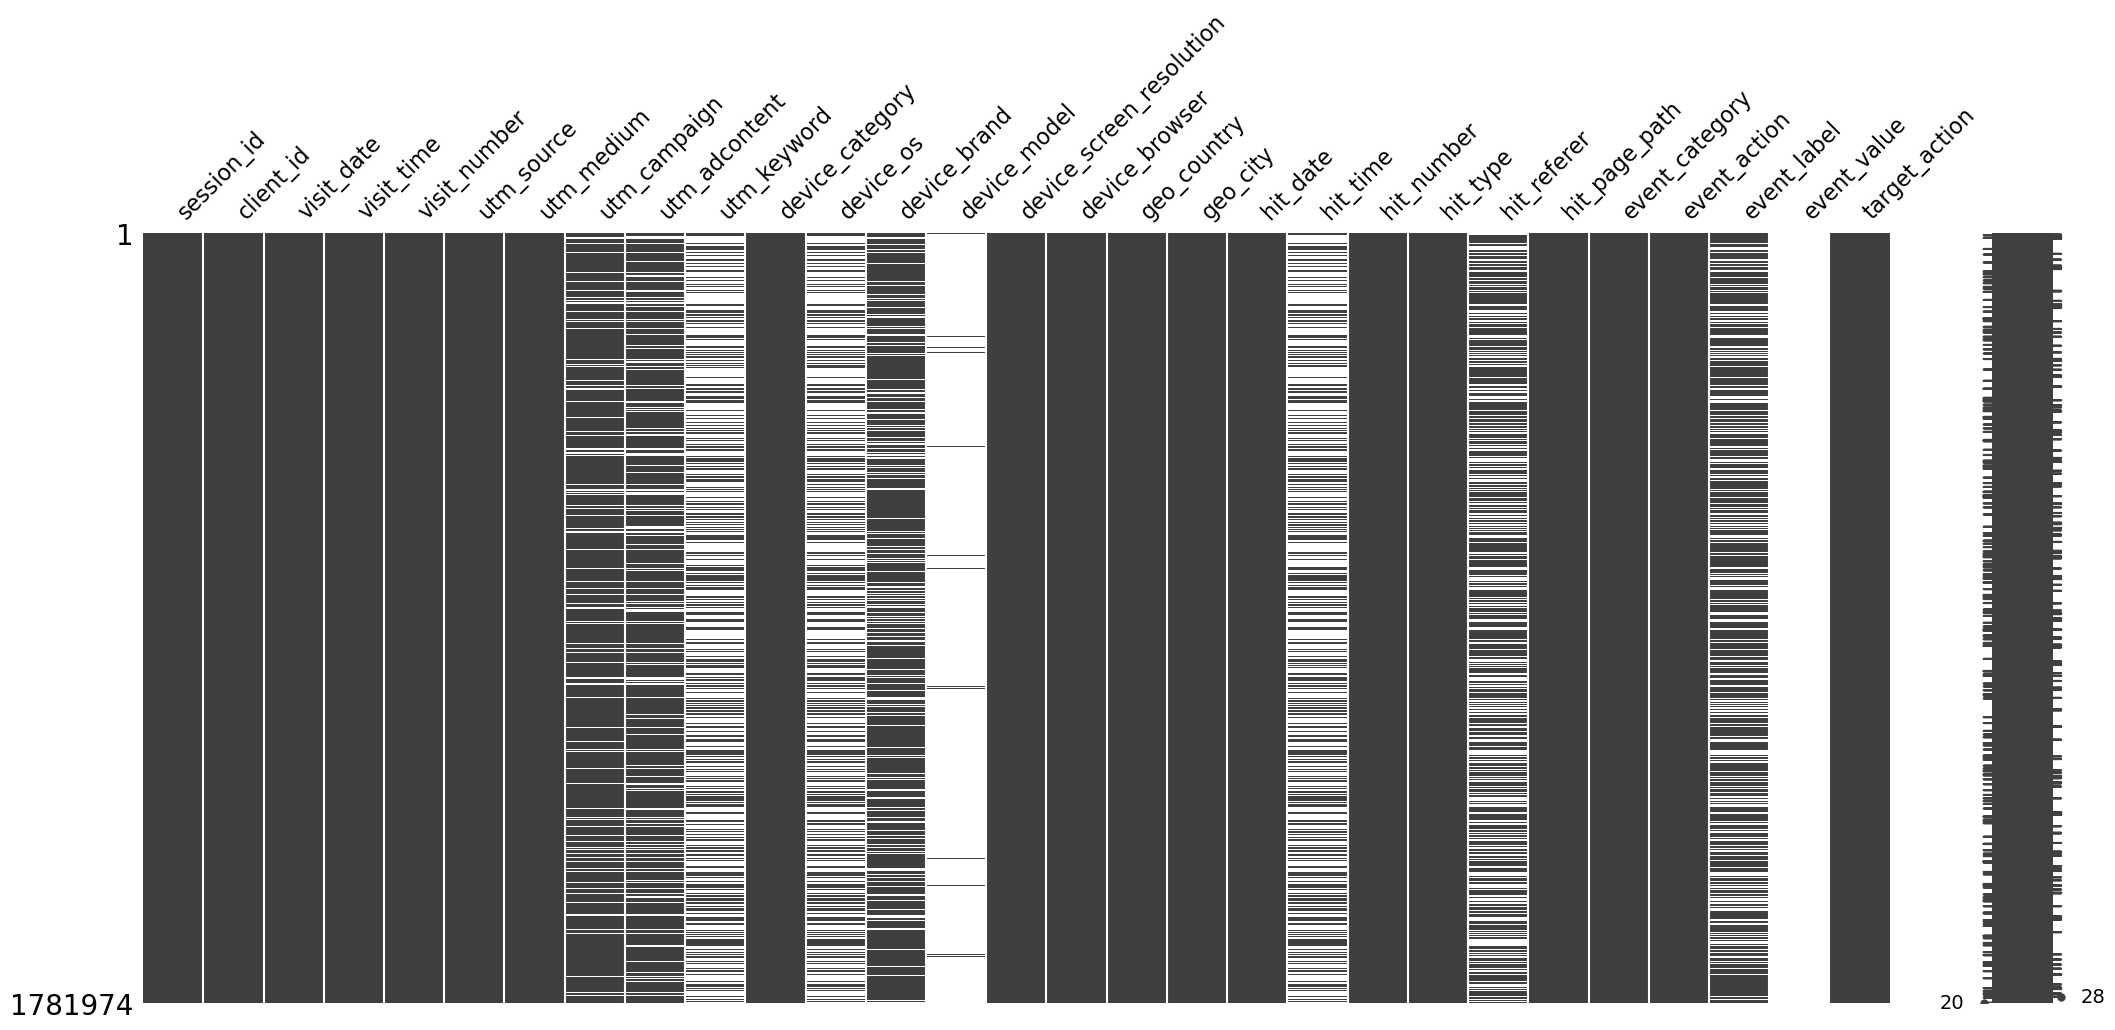

In [30]:
msno.matrix(df_cleaned)

<Axes: >

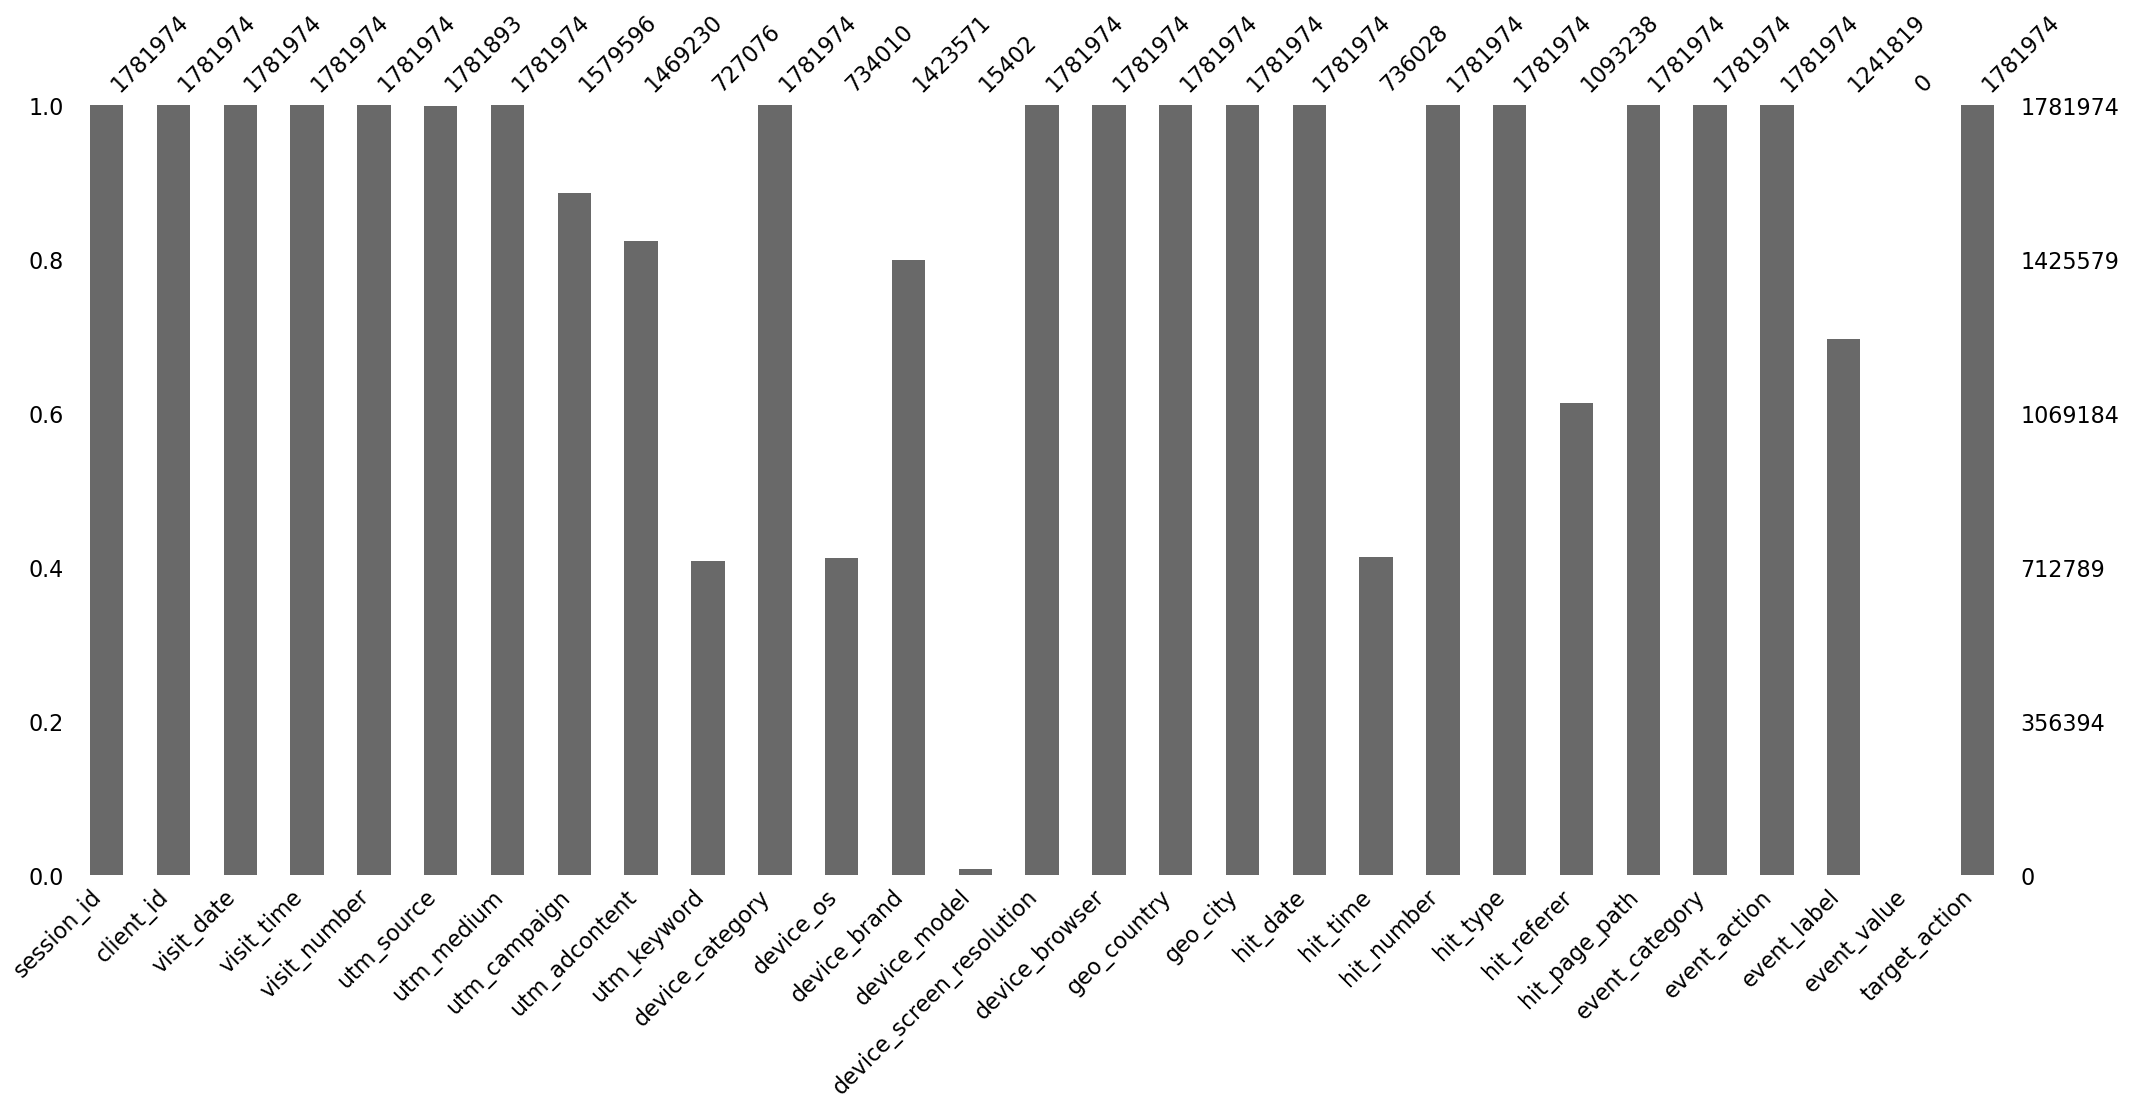

In [31]:
msno.bar(df_cleaned)

In [32]:
missing_values=((df_cleaned.isna().sum()/len(df_cleaned))*100).sort_values()
missing_values

session_id                    0.000000
event_action                  0.000000
event_category                0.000000
hit_page_path                 0.000000
hit_type                      0.000000
hit_number                    0.000000
hit_date                      0.000000
geo_city                      0.000000
geo_country                   0.000000
device_browser                0.000000
device_screen_resolution      0.000000
target_action                 0.000000
client_id                     0.000000
visit_date                    0.000000
utm_medium                    0.000000
device_category               0.000000
visit_number                  0.000000
visit_time                    0.000000
utm_source                    0.004546
utm_campaign                 11.356956
utm_adcontent                17.550424
device_brand                 20.112695
event_label                  30.312171
hit_referer                  38.650171
hit_time                     58.695918
device_os                

### Обработка пропусков

In [34]:
df_pass=df_cleaned.copy()

In [35]:
print(df_pass['hit_referer'].value_counts()) # в выборке он не учавствует поэтому столбец будет убран

hit_referer
HbolMJUevblAbkHClEQa    985916
sAGDBCdeVPmQPwkVEcIX     19949
FwdMTcXzWAwhtsnMAbhS     11246
GQmOLxANuSeCxCanBpMl      8908
NfSAiKHBqffzsXrbjcSr      6757
                         ...  
YFNbqrGiBTjmllVXUZJJ         1
JXIeqdLSzQYfBgGpQFie         1
rzqyXvejbueTDkYMQVEx         1
FGjcGcnGyQUJUeCeWzFF         1
YYdePVtRDGSqtVNklUHV         1
Name: count, Length: 24693, dtype: int64


In [36]:
print(df_pass['hit_time'].value_counts()) # в выборке он не учавствует поэтому столбец будет убран

hit_time
0.0         21729
1.0          5665
2.0          2573
3.0          1537
60.0         1234
            ...  
686451.0        1
45293.0         1
78825.0         1
315738.0        1
70087.0         1
Name: count, Length: 198296, dtype: int64


In [37]:
df_pass = df_pass.drop(columns=['device_model', 'event_value']) #Убираем неинформативные столбцы

#### Обработка utm

In [39]:
def extract_utm_params(url, param_name):
    if not isinstance(url, str):
        return None 

    pattern = re.compile(r"" + re.escape(param_name) + "=([^&]+)")
    match = pattern.search(url)

    if match:
        return match.group(1)  # Возвращаем захваченную группу (значение между param_name= и &)
    else:
        return None

In [40]:
df_pass['hit_page_path'] = df_pass['hit_page_path'].astype(str)

# Создаем временные столбцы
df_pass['utm_campaign_new'] = df_pass['hit_page_path'].apply(lambda x: extract_utm_params(x, 'utm_campaign_initial'))
df_pass['utm_adcontent_new'] = df_pass['hit_page_path'].apply(lambda x: extract_utm_params(x, 'utm_content_initial'))
df_pass['utm_keyword_new'] = df_pass['hit_page_path'].apply(lambda x: extract_utm_params(x, 'utm_term_initial'))

# Обновляем столбцы, только если во временных столбцах не NaN
df_pass['utm_campaign'] = df_pass.apply(lambda row: row['utm_campaign_new'] if pd.notna(row['utm_campaign_new']) else row['utm_campaign'], axis=1)
df_pass['utm_adcontent'] = df_pass.apply(lambda row: row['utm_adcontent_new'] if pd.notna(row['utm_adcontent_new']) else row['utm_adcontent'], axis=1)
df_pass['utm_keyword'] = df_pass.apply(lambda row: row['utm_keyword_new'] if pd.notna(row['utm_keyword_new']) else row['utm_keyword'], axis=1)


df_pass = df_pass.drop(columns=['utm_campaign_new', 'utm_adcontent_new', 'utm_keyword_new'])


print(df_pass[['hit_page_path', 'utm_campaign', 'utm_adcontent', 'utm_keyword']].head())

                                        hit_page_path          utm_campaign  \
0                              podpiska.sberauto.com/  LEoPHuyFvzoNfnzGgfcd   
2                              podpiska.sberauto.com/  FTjNLDyTrXaWYgZymFkV   
3   sberauto.com/cars?utm_source_initial=sbol&utm_...  LEoPHuyFvzoNfnzGgfcd   
19                             podpiska.sberauto.com/                   NaN   
22  sberauto.com/cars?city=1&rental_page=rental_on...                   NaN   

           utm_adcontent           utm_keyword  
0   vCIpmpaGBnIQhyYNkXqp  puhZPIYqKXeFPaUviSjo  
2   xhoenQgDQsgfEPYNPwKO  IGUCNvHlhfHpROGclCit  
3   vCIpmpaGBnIQhyYNkXqp  puhZPIYqKXeFPaUviSjo  
19  NOBKLgtuvqYWkXQHeYWM                   NaN  
22                   NaN                   NaN  


In [41]:
# Для категориальных признаков выбираем заменить наиболее популярным значением признаки
cols = ['utm_campaign', 'utm_adcontent', 'utm_keyword', 'utm_source']
modes = {col: df_pass[col].mode()[0] for col in cols}
df_pass[cols] = df_pass[cols].fillna(modes)

In [42]:
df_pass['utm_campaign'] = df_pass['utm_campaign'].apply(lambda x: 'other' if len(x) < 20 else x[:20])

#### Обработка device

In [44]:
unique_device_categories = df_pass['device_category'].unique()
print(unique_device_categories)

['mobile' 'tablet' 'desktop']


In [45]:
print(df_pass['device_brand'].value_counts()) # какие у нас есть Бренды

device_brand
Apple           517859
Samsung         321626
Xiaomi          275796
Huawei          178330
Realme           18347
                 ...  
Cube                 1
Star                 1
Mobiistar            1
Dragon Touch         1
Maxvi                1
Name: count, Length: 200, dtype: int64


In [46]:
def kill_nan_brands(df_pass): #Заполняем пропуски самым популярным значением для  каждой категории
    
    most_frequent_brand = df_pass.groupby('device_category')['device_brand'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'other')
    df_pass['device_brand'] = df_pass['device_brand'].fillna(df_pass['device_category'].map(most_frequent_brand))
    return df_pass

df_pass = kill_nan_brands(df_pass)

In [47]:
print(df_pass['device_os'].value_counts()) # какие у нас есть ОС

device_os
Android          434929
iOS              186484
Windows           83321
Macintosh         24156
Linux              4706
(not set)           309
Chrome OS            65
BlackBerry           24
Tizen                 7
Firefox OS            3
Nokia                 2
Samsung               2
Windows Phone         2
Name: count, dtype: int64


In [48]:
def kill_nan_os(df_pass):
    mask_apple = (df_pass['device_brand'] == 'Apple') & (df_pass['device_os'].isna())
    df_pass.loc[mask_apple, 'device_os'] = 'iOS'
    mask_android = df_pass['device_os'].isna()
    df_pass.loc[mask_android, 'device_os'] = 'Android'
    return df_pass

df_pass=kill_nan_os(df_pass)

### Проверка на пропуски Конечная

In [50]:
missing_values=((df_pass.isna().sum()/len(df_pass))*100).sort_values()
missing_values

session_id                   0.000000
event_action                 0.000000
event_category               0.000000
hit_page_path                0.000000
hit_type                     0.000000
hit_number                   0.000000
hit_date                     0.000000
geo_city                     0.000000
geo_country                  0.000000
device_browser               0.000000
device_brand                 0.000000
device_screen_resolution     0.000000
device_category              0.000000
utm_keyword                  0.000000
utm_adcontent                0.000000
utm_campaign                 0.000000
utm_medium                   0.000000
utm_source                   0.000000
visit_number                 0.000000
visit_time                   0.000000
visit_date                   0.000000
client_id                    0.000000
device_os                    0.000000
target_action                0.000000
event_label                 30.312171
hit_referer                 38.650171
hit_time    

Последние 3 значения не будут использованы и удалятся на следующем шагу.

# Feature engineering

In [53]:
columns_to_drop = [
    'session_id',
    'client_id',
    'visit_date',
    'visit_time',
    'visit_number',
    'hit_time',
    'hit_number',
    'hit_type',
    'hit_referer',
    'hit_page_path',
    'event_category',
    'event_action',
    'event_label',
    'device_screen_resolution',
    'utm_adcontent',
    'hit_date'
    
    

]
df_clean=df_pass.copy()
df_clean.drop(columns_to_drop, axis=1, inplace=True)
missing_values=((df_clean.isna().sum()/len(df_clean))*100).sort_values()
missing_values

utm_source         0.0
utm_medium         0.0
utm_campaign       0.0
utm_keyword        0.0
device_category    0.0
device_os          0.0
device_brand       0.0
device_browser     0.0
geo_country        0.0
geo_city           0.0
target_action      0.0
dtype: float64

In [54]:
print(df_clean.shape) 

(1781974, 11)


### Сокращаем количество фичей

Аппаратная часть не может вычислить огромное количество - сокращаем. 

In [57]:
def group_rare_data(df, top_n_utm_source=50,top_n_device_browser=10 ,top_n_utm_medium=25, top_n_device_os=5, top_n_utm_keyword =30, top_n_utm_campaign=100, top_n_device_brand=50, top_n_geo_city=100, top_n_geo_country=50, rare_category="Other"):
    """Groups rare values in specified columns into a single category."""
    group_cols = {
        'utm_medium': top_n_utm_medium,
        'utm_source': top_n_utm_source,
        'utm_campaign': top_n_utm_campaign,
        'device_browser': top_n_device_browser,
        'device_brand': top_n_device_brand,
        'device_os': top_n_device_os,
        'geo_city': top_n_geo_city,
        'utm_keyword': top_n_utm_keyword,
        'geo_country': top_n_geo_country
    }

    for col, top_n in group_cols.items():
        top_values = df[col].value_counts().head(top_n).index
        df[col] = df[col].where(df[col].isin(top_values), rare_category)

    return df

df_clean = group_rare_data(df_clean)

In [58]:
for column in df_clean.columns:
    num_unique = df_clean[column].nunique()
    print(f"Столбец '{column}': {num_unique} уникальных значений")

Столбец 'utm_source': 51 уникальных значений
Столбец 'utm_medium': 26 уникальных значений
Столбец 'utm_campaign': 101 уникальных значений
Столбец 'utm_keyword': 31 уникальных значений
Столбец 'device_category': 3 уникальных значений
Столбец 'device_os': 6 уникальных значений
Столбец 'device_brand': 51 уникальных значений
Столбец 'device_browser': 11 уникальных значений
Столбец 'geo_country': 51 уникальных значений
Столбец 'geo_city': 101 уникальных значений
Столбец 'target_action': 2 уникальных значений


### Сокращаем количество значений

In [60]:
# Скоращаем количество значений (1.8 млн. это много, но при этом у нас большая разница между True и False в "target_action")

In [61]:
def remove_duplicate_rows(df_clean, columns_to_check):
    """Removes duplicate rows where 'target_action' is False, based on specified columns."""
    duplicates = df.duplicated(subset=columns_to_check, keep='first')
    df_clean = df_clean[~duplicates].copy()  # Добавляем .copy()

    return df_clean

columns_to_check = [
    'utm_medium', 'utm_source', 'utm_campaign', 'device_category',
    'device_os', 'device_brand', 'device_browser', 'geo_country',
    'geo_city', 'target_action','utm_keyword'
]

df_fin_cleaned = remove_duplicate_rows(df_clean, columns_to_check)
print(f"Original DataFrame size: {len(df_clean)}")
print(f"Cleaned DataFrame size: {len(df_fin_cleaned)}")


C:\Users\Toshik\AppData\Local\Temp\ipykernel_24216\599323720.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_clean[~duplicates].copy()  # Добавляем .copy()


Original DataFrame size: 1781974
Cleaned DataFrame size: 190449


In [62]:
counts = df_fin_cleaned['target_action'].value_counts()
print(counts)

target_action
False    176088
True      14361
Name: count, dtype: int64


In [63]:
def get_target_action_counts_by_medium(df_fin_cleaned):


  stats = df_fin_cleaned.groupby('utm_keyword')['target_action'].value_counts().unstack(fill_value=0)
  stats = stats.sort_values(by=True, ascending=False)  # Сортируем по столбцу 'True'
  return stats

target_action_counts = get_target_action_counts_by_medium(df_fin_cleaned)
print(target_action_counts)

target_action          False  True 
utm_keyword                        
puhZPIYqKXeFPaUviSjo  124735  11386
Other                  30657   1743
ITfrGJNwVsHBGJMAKoct    2350    237
UKNBOHebRIIsQRsjNKay    1630    138
ZNhSIPchlbnKwZWcsKzz     933     95
hAmNSZmQkKQKAjZEGlgb    1532     88
JajANoFxoqXfKRNBUhzx     854     70
XEayFbemrPYbxFeNbxif     567     58
RkpOyeEPgcMBSDuHLQcj     805     49
aXQzDWsJuGXeBXexNHjc    1872     46
tVtbIKrPSOvrXLCznVVe     606     42
pHqgLcdBQPSLcrTpLkdr     957     39
IGUCNvHlhfHpROGclCit     755     38
KCcEkEaKEtUilBVMoCAi     533     35
QYfbqJXuLdJGfOSFgZOs     515     34
YQXPpoLsxnykCWKhGEmI     539     33
psjAUzFZVWWCuxgCrtmQ     511     32
COtBsnAzfZyRVtvDlhnW     420     30
BmOOOIoWGHEfxEfoUezs     745     29
RrhnkuoaqckNtJpAZDzH     580     28
pucKZkLDtpMDBTobJAJG     514     26
DBHgBJHOdbPwsRDUbEgX     486     19
MWLEpQPyjGkjHseVyeyQ     439     17
qxnAydKMtMSuafVrMzdC     394     15
fzbotReoFzSuckjwcpCs     403     14
tzIeQUUHahhBuEkJqDVp     827

### Приводим категориальные признаки

In [65]:
columns_to_encode = [
     
    'utm_medium', 
    'utm_source',
    'utm_campaign', 
    'device_category', 
    'device_brand', 
    'device_os', 
    'geo_country',
    'geo_city',
    'utm_keyword',
    'device_browser'
    
]


In [66]:
df_fin=df_fin_cleaned.copy()

In [67]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = encoder.fit_transform(df_fin[columns_to_encode])
encoded_cols = encoder.get_feature_names_out(columns_to_encode)
df_encoded = pd.DataFrame(encoded_data, columns=encoded_cols, index=df_fin.index)
df_fin = pd.concat([df_fin, df_encoded], axis=1)
df_fin.head()

,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,device_browser,geo_country,geo_city,...,device_browser_Chrome,device_browser_Edge,device_browser_Firefox,device_browser_Opera,device_browser_Other,device_browser_Safari,device_browser_Safari (in-app),device_browser_Samsung Internet,device_browser_UC Browser,device_browser_YaBrowser
0,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,Chrome,Russia,Other,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,Samsung Internet,Russia,Moscow,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,Chrome,Russia,Krasnoyarsk,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,kjsLglQLzykiRbcDiGcD,cpc,LTuZkdKfxRGVceoWkVyg,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,Chrome,Russia,Moscow,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,Safari,Russia,Saint Petersburg,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [68]:
df_fin.drop(columns_to_encode, axis=1, inplace=True)

#### Ищем значения для проверки

In [70]:
filtered_df = df_fin[df_fin['target_action'] == True]
filtered_df.head()

,target_action,utm_medium_(none),utm_medium_(not set),utm_medium_Other,utm_medium_app,utm_medium_banner,utm_medium_blogger_channel,utm_medium_blogger_header,utm_medium_blogger_stories,utm_medium_clicks,...,device_browser_Chrome,device_browser_Edge,device_browser_Firefox,device_browser_Opera,device_browser_Other,device_browser_Safari,device_browser_Safari (in-app),device_browser_Samsung Internet,device_browser_UC Browser,device_browser_YaBrowser
678,True,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
712,True,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
777,True,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1273,True,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1358,True,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [218]:
filtered_df = df_fin[df_fin['target_action'] == True]
row = filtered_df.loc[1358]
columns_True = row[row == 1.0].index.tolist()
print(f"\nТолько столбцы со значением 1.0:\n{row[columns_True]}")


Только столбцы со значением 1.0:
target_action                        True
utm_medium_banner                     1.0
utm_source_ZpYIoDJMcFzVoPFsHGJL       1.0
utm_campaign_LEoPHuyFvzoNfnzGgfcd     1.0
device_category_mobile                1.0
device_brand_Samsung                  1.0
device_os_Android                     1.0
geo_country_Russia                    1.0
geo_city_Moscow                       1.0
utm_keyword_puhZPIYqKXeFPaUviSjo      1.0
device_browser_Chrome                 1.0
Name: 1358, dtype: object


In [234]:
filtered_df = df_fin[df_fin['target_action'] == False]
filtered_df.head(50)

,target_action,utm_medium_(none),utm_medium_(not set),utm_medium_Other,utm_medium_app,utm_medium_banner,utm_medium_blogger_channel,utm_medium_blogger_header,utm_medium_blogger_stories,utm_medium_clicks,...,device_browser_Chrome,device_browser_Edge,device_browser_Firefox,device_browser_Opera,device_browser_Other,device_browser_Safari,device_browser_Safari (in-app),device_browser_Samsung Internet,device_browser_UC Browser,device_browser_YaBrowser
0,False,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,False,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
83,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
89,False,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,False,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
108,False,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
119,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [238]:
filtered_df = df_fin[df_fin['target_action'] == False]
row = filtered_df.loc[517]
columns_True = row[row == 1.0].index.tolist()
print(f"\nТолько столбцы со значением 1.0:\n{row[columns_True]}")


Только столбцы со значением 1.0:
utm_medium_banner                    1.0
utm_source_ZpYIoDJMcFzVoPFsHGJL      1.0
utm_campaign_gecBYcKZCPMcVYdSSzKP    1.0
device_category_mobile               1.0
device_brand_Meizu                   1.0
device_os_Android                    1.0
geo_country_Russia                   1.0
geo_city_Moscow                      1.0
utm_keyword_puhZPIYqKXeFPaUviSjo     1.0
device_browser_Chrome                1.0
Name: 517, dtype: object


# Modeling

In [75]:
df_modeling=df_fin.copy()

In [76]:
counts = df_modeling['target_action'].value_counts()
print(counts)

target_action
False    176088
True      14361
Name: count, dtype: int64


In [77]:
X = df_modeling.drop(['target_action'], axis=1)
y = df_modeling['target_action']

models = [
    LogisticRegression(solver='liblinear', max_iter=1000, penalty='l1', C=0.1, class_weight='balanced'),  # Указываем solver class_weight='balanced', random_state=42, solver='liblinear' #0.8958
    RandomForestClassifier(max_depth=15, min_samples_leaf=2, class_weight='balanced'),#class_weight='balanced', random_state=42 #0.8429 
    CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6,verbose=False),
    MLPClassifier() 

In [78]:
for m in models:
    score = cross_val_score(m, X, y, cv=4, scoring='accuracy')
    print(f'model: {type(m).__name__}, acc_mean: {score.mean():.4f}, acc_std: {score.std():.4f}')

model: LogisticRegression, acc_mean: 0.6694, acc_std: 0.1100
model: RandomForestClassifier, acc_mean: 0.6601, acc_std: 0.0777
model: CatBoostClassifier, acc_mean: 0.9175, acc_std: 0.0120


C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


model: MLPClassifier, acc_mean: 0.8890, acc_std: 0.0437


C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


#### Выводы

Дисбаланс классов приводит неверной интерпритации "accuracy", высокий показатель указывает на определение только одного из классов.

In [89]:
from sklearn.metrics import classification_report,precision_score, recall_score, f1_score, roc_auc_score
import seaborn as sns

def evaluate_model(y_test, y_pred, y_pred_proba=None):
   
    conf_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(classification_report(y_test, y_pred))
    print(f"Confusion Matrix:\n{conf_matrix}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

   

              precision    recall  f1-score   support

       False       0.97      0.67      0.79     52747
        True       0.15      0.72      0.25      4388

    accuracy                           0.67     57135
   macro avg       0.56      0.70      0.52     57135
weighted avg       0.90      0.67      0.75     57135

Confusion Matrix:
[[35391 17356]
 [ 1223  3165]]
Accuracy: 0.6748
Precision: 0.1542
Recall: 0.7213
F1-score: 0.2541
ROC AUC: 0.7607


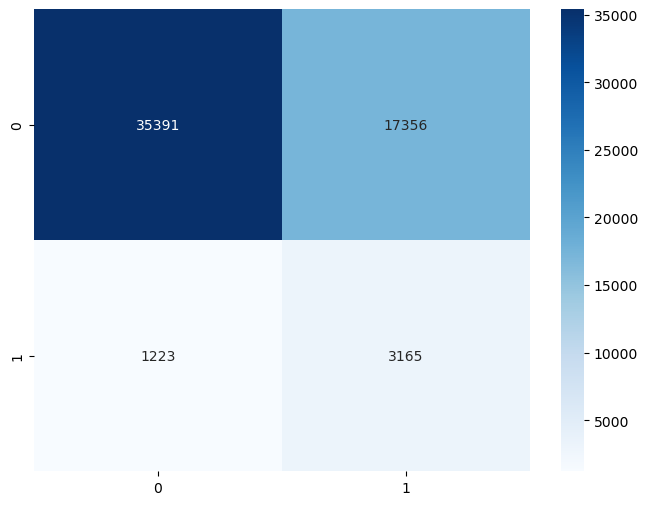

In [91]:
# Логистическая регрессия на сырых данных
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(solver='liblinear', max_iter=1000, penalty='l1', C=0.1, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] 

evaluate_model(y_test, y_pred, y_pred_proba)

              precision    recall  f1-score   support

       False       0.96      0.67      0.79     52747
        True       0.14      0.65      0.23      4388

    accuracy                           0.67     57135
   macro avg       0.55      0.66      0.51     57135
weighted avg       0.90      0.67      0.75     57135

Confusion Matrix:
[[35391 17356]
 [ 1524  2864]]
Accuracy: 0.6696
Precision: 0.1416
Recall: 0.6527
F1-score: 0.2328
ROC AUC: 0.7296


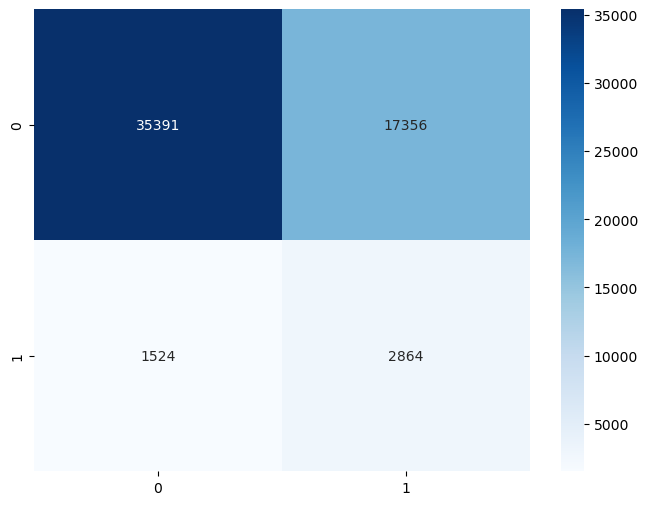

In [93]:
# Случайный лес на сырых данных
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model1 = RandomForestClassifier(max_depth=15, min_samples_leaf=2, class_weight='balanced')
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test) 
y_pred_proba = model1.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_pred_proba)



              precision    recall  f1-score   support

       False       0.96      0.63      0.76     52747
        True       0.13      0.67      0.22      4388

    accuracy                           0.63     57135
   macro avg       0.54      0.65      0.49     57135
weighted avg       0.90      0.63      0.72     57135

Confusion Matrix:
[[33208 19539]
 [ 1434  2954]]
Accuracy: 0.6329
Precision: 0.1313
Recall: 0.6732
F1-score: 0.2198
ROC AUC: 0.7091


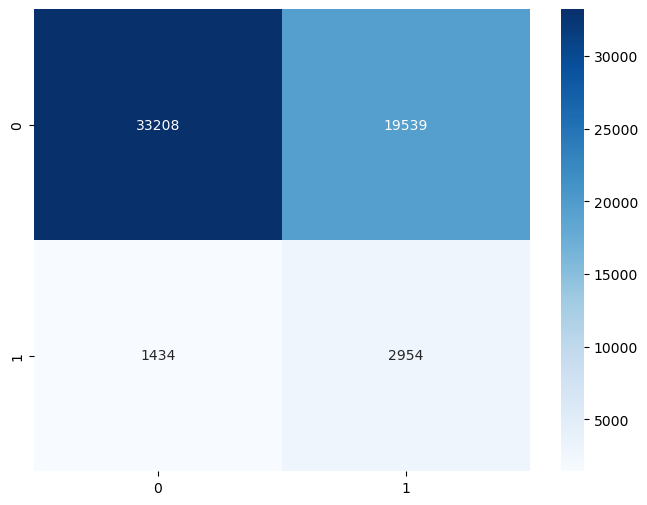

In [111]:
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Применение  CatBoost на сырых данных

model2 = CatBoostClassifier(iterations=100, learning_rate=0.01, depth=6, random_state=42,verbose=False, auto_class_weights='Balanced')



model2.fit(X_train, y_train)
y_pred = model2.predict(X_test) 
y_pred_proba = model2.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_pred_proba)

C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


              precision    recall  f1-score   support

       False       0.96      0.80      0.87     52827
        True       0.18      0.54      0.27      4308

    accuracy                           0.78     57135
   macro avg       0.57      0.67      0.57     57135
weighted avg       0.90      0.78      0.83     57135

Confusion Matrix:
[[42353 10474]
 [ 1961  2347]]
Accuracy: 0.7824
Precision: 0.1831
Recall: 0.5448
F1-score: 0.2740
ROC AUC: 0.7479


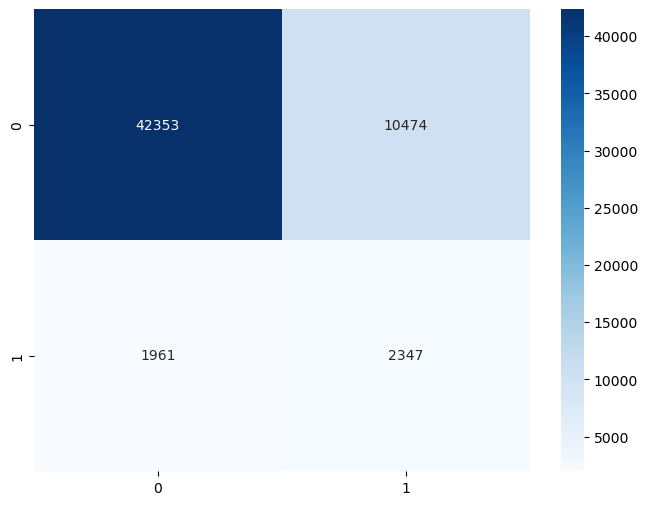

In [206]:
from imblearn.under_sampling import RandomUnderSampler
#Применение Даунсэмплинга

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) 


rus = RandomUnderSampler(random_state=42, sampling_strategy=0.7)  
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)


model3 = RandomForestClassifier(max_depth=10, min_samples_leaf=5, max_features=0.7 ,n_estimators=500)
model3.fit(X_train_resampled, y_train_resampled)

y_pred = model3.predict(X_test)
y_pred_proba = model3.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_pred_proba)


C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


              precision    recall  f1-score   support

       False       0.96      0.81      0.88     52827
        True       0.19      0.54      0.28      4308

    accuracy                           0.79     57135
   macro avg       0.57      0.68      0.58     57135
weighted avg       0.90      0.79      0.83     57135

Confusion Matrix:
[[42740 10087]
 [ 1964  2344]]
Accuracy: 0.7891
Precision: 0.1886
Recall: 0.5441
F1-score: 0.2801
ROC AUC: 0.7582


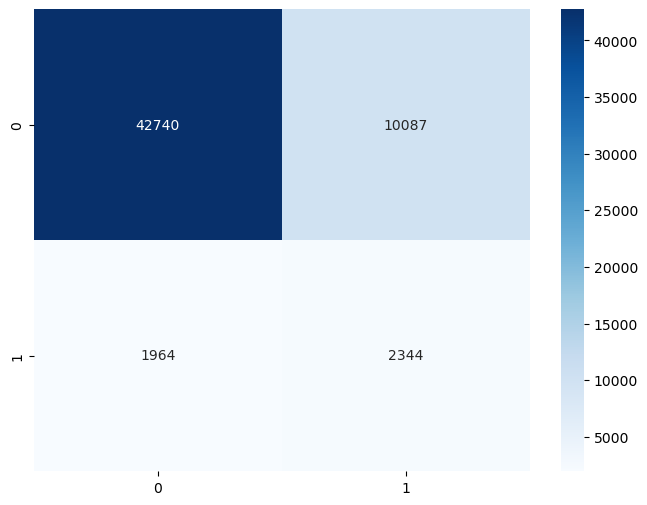

In [137]:
from imblearn.under_sampling import RandomUnderSampler

#Применение Даунсэмплинга, и без балансировки  повышает повышает точность в нахождении True

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # stratify=y для сохранения пропорций классов


rus = RandomUnderSampler(random_state=42, sampling_strategy=0.7)  #  random_state для воспроизводимости
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)


model3 = LogisticRegression(solver='liblinear', max_iter=1000, penalty='l1', C=0.1)
model3.fit(X_train_resampled, y_train_resampled)

y_pred = model3.predict(X_test)
y_pred_proba = model3.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_pred_proba)

C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


              precision    recall  f1-score   support

       False       0.96      0.82      0.88     52827
        True       0.21      0.58      0.30      4308

    accuracy                           0.80     57135
   macro avg       0.58      0.70      0.59     57135
weighted avg       0.90      0.80      0.84     57135

Confusion Matrix:
[[43264  9563]
 [ 1816  2492]]
Accuracy: 0.8008
Precision: 0.2067
Recall: 0.5785
F1-score: 0.3046
ROC AUC: 0.7777


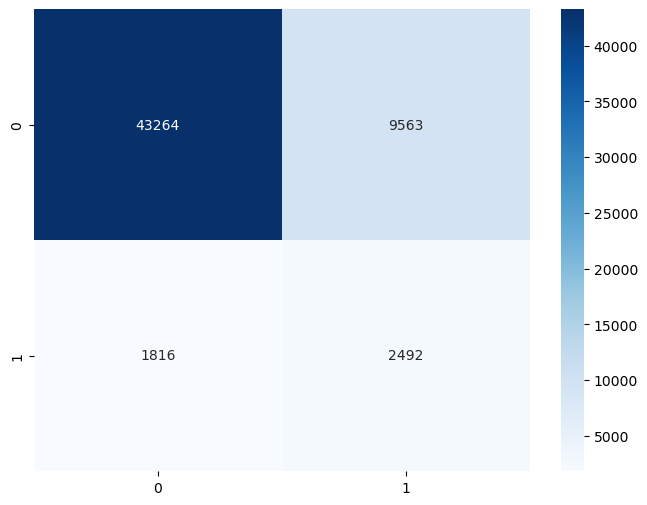

In [154]:
from imblearn.under_sampling import RandomUnderSampler

#Применение Даунсэмплинга, и без балансировки  повышает повышает точность в нахождении True

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # stratify=y для сохранения пропорций классов


rus = RandomUnderSampler(random_state=42, sampling_strategy=0.7)  #  random_state для воспроизводимости
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)


model3 = MLPClassifier(random_state=42, max_iter=50, activation='logistic',  hidden_layer_sizes=(256, 128), alpha=0.01, solver='adam', learning_rate_init=0.01, validation_fraction=0.2)
model3.fit(X_train_resampled, y_train_resampled)

y_pred = model3.predict(X_test)
y_pred_proba = model3.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_pred_proba)

C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


              precision    recall  f1-score   support

       False       0.95      0.82      0.88     52827
        True       0.18      0.46      0.25      4308

    accuracy                           0.80     57135
   macro avg       0.56      0.64      0.57     57135
weighted avg       0.89      0.80      0.83     57135

Confusion Matrix:
[[43421  9406]
 [ 2306  2002]]
Accuracy: 0.7950
Precision: 0.1755
Recall: 0.4647
F1-score: 0.2548
ROC AUC: 0.7270


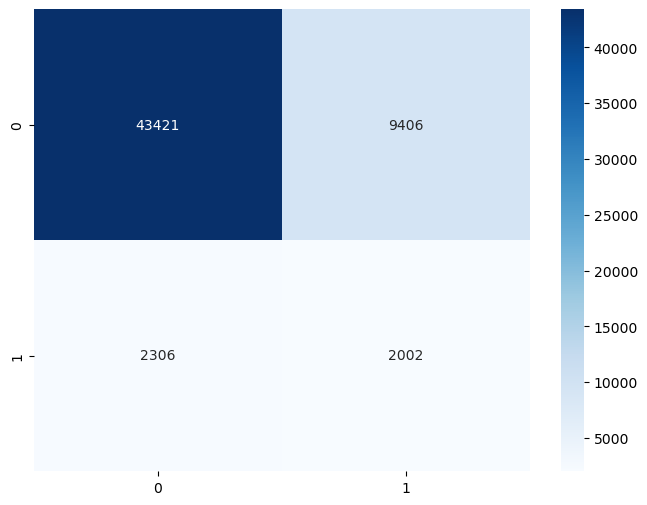

In [148]:
from imblearn.under_sampling import RandomUnderSampler

# Применение Даунсэмлинга и CatBoost

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # stratify=y для сохранения пропорций классов


rus = RandomUnderSampler(random_state=42, sampling_strategy=0.7)  #  random_state для воспроизводимости
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)


model3 =  CatBoostClassifier(iterations=1000,
                             learning_rate=0.001,
                             depth=8,
                             random_state=42,
                             verbose=False,
                             cat_features=categorical_features_indices)
model3.fit(X_train_resampled, y_train_resampled)

y_pred = model3.predict(X_test)
y_pred_proba = model3.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_pred_proba)

C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


              precision    recall  f1-score   support

       False       0.96      0.71      0.82     52827
        True       0.15      0.61      0.24      4308

    accuracy                           0.70     57135
   macro avg       0.55      0.66      0.53     57135
weighted avg       0.90      0.70      0.77     57135

Confusion Matrix:
[[37531 15296]
 [ 1665  2643]]
Accuracy: 0.7031
Precision: 0.1473
Recall: 0.6135
F1-score: 0.2376
ROC AUC: 0.6839


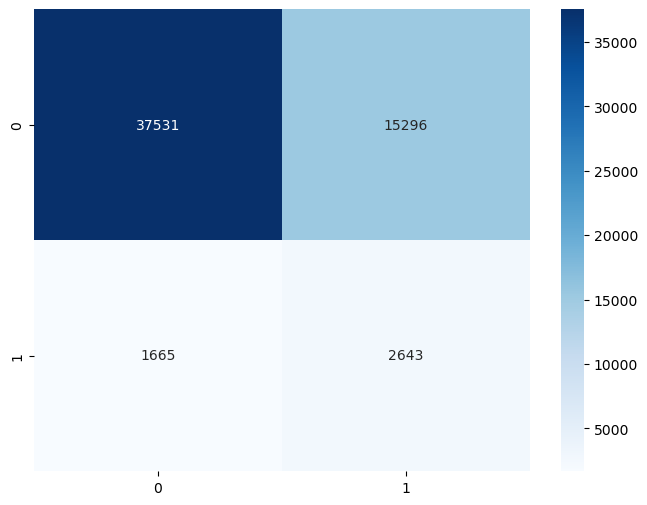

In [136]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # stratify=y для сохранения пропорций классов
# Применение SMOT

smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)


model3 = RandomForestClassifier( class_weight='balanced')
model3.fit(X_train_resampled, y_train_resampled)

y_pred = model3.predict(X_test)
y_pred_proba = model3.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_pred_proba)


C:\Users\Toshik\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


              precision    recall  f1-score   support

       False       0.97      0.67      0.79     52827
        True       0.15      0.74      0.25      4308

    accuracy                           0.67     57135
   macro avg       0.56      0.70      0.52     57135
weighted avg       0.91      0.67      0.75     57135

Confusion Matrix:
[[35212 17615]
 [ 1131  3177]]
Accuracy: 0.6719
Precision: 0.1528
Recall: 0.7375
F1-score: 0.2531
ROC AUC: 0.7687


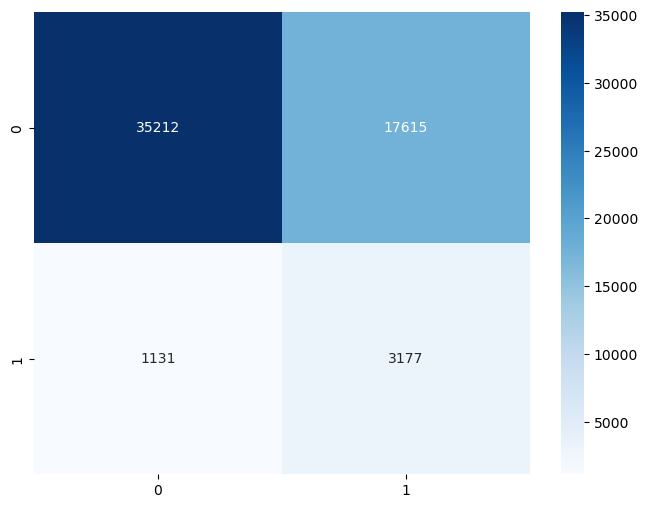

In [110]:
from imblearn.under_sampling import TomekLinks
# Применение Даунсэмплинга ( Томэк Линка)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # stratify=y для сохранения пропорций классов

tl = TomekLinks()
X_train_resampled, y_train_resampled = tl.fit_resample(X_train, y_train)

model4 = LogisticRegression(solver='liblinear', max_iter=1000, penalty='l1', C=0.1, class_weight='balanced')
model4.fit(X_train_resampled, y_train_resampled)

y_pred = model4.predict(X_test)
y_pred_proba = model4.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_pred_proba)


Вывод для сервиса: были выбраны лучшие сочетания для сырых данных и использования "balanced", а так же 4 наилучше настроенных модели для использования вместе с даунсэмпингом.